# COMP90055 Project

## Experiment Graphs

In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt

## 1. System Performance

In [8]:
with open("../experiments/ver1_expRes.json", "r") as f:
     sys_results = json.load(f)

In [10]:
len(sys_results)

180

Success Rate: 79.44%
Average Runtime (sec): 25.44
Average Top-5 Recall: 0.50
Average Distance Deviation (m): 2364.05
Error Rate: 20.56%


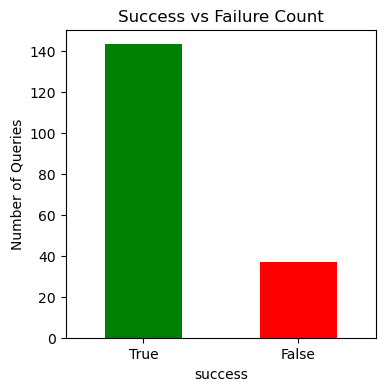

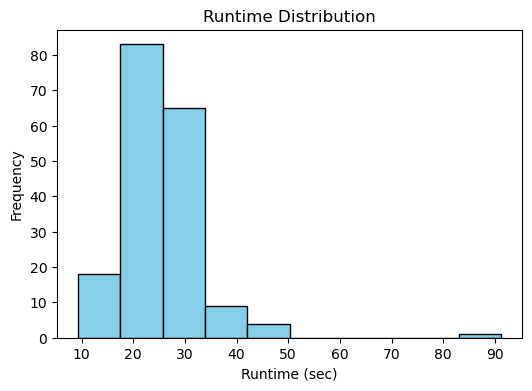

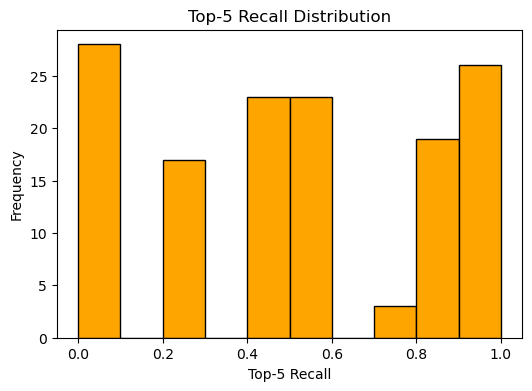

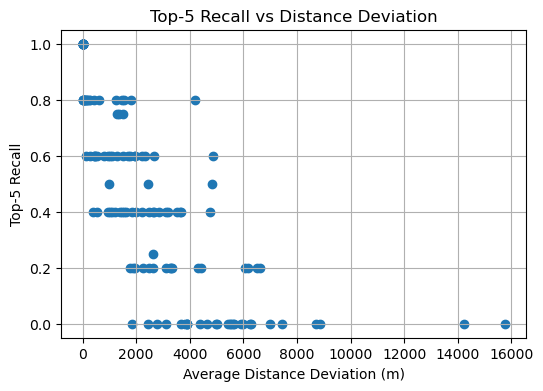

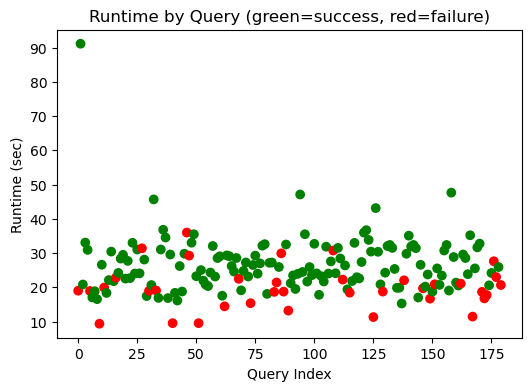

In [11]:
# Convert to DataFrame
df = pd.DataFrame(sys_results)

# ---- Compute summary metrics ----
success_rate = df['success'].mean()  # proportion of True
avg_runtime = df['runtime_sec'].mean()

# Handle possible None/NaN
avg_top5_recall = df['top5_recall'].dropna().mean()
avg_dist_dev = df['avg_dist_dev_m'].dropna().mean()

print(f"Success Rate: {success_rate:.2%}")
print(f"Average Runtime (sec): {avg_runtime:.2f}")
print(f"Average Top-5 Recall: {avg_top5_recall:.2f}")
print(f"Average Distance Deviation (m): {avg_dist_dev:.2f}")

# You can also compute other metrics:
# e.g. error rate
error_rate = df['error'].notna().mean()
print(f"Error Rate: {error_rate:.2%}")

# ---- Draw some graphs ----

# 1. Success vs Fail Count
plt.figure(figsize=(4,4))
df['success'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Success vs Failure Count')
plt.ylabel('Number of Queries')
plt.xticks(rotation=0)
plt.show()

# 2. Runtime distribution
plt.figure(figsize=(6,4))
df['runtime_sec'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.title('Runtime Distribution')
plt.xlabel('Runtime (sec)')
plt.ylabel('Frequency')
plt.show()

# 3. Top-5 Recall distribution
plt.figure(figsize=(6,4))
df['top5_recall'].dropna().plot(kind='hist', bins=10, color='orange', edgecolor='black')
plt.title('Top-5 Recall Distribution')
plt.xlabel('Top-5 Recall')
plt.ylabel('Frequency')
plt.show()

# 4. Scatter plot: Distance deviation vs Top5 recall
if df['avg_dist_dev_m'].notna().any() and df['top5_recall'].notna().any():
    plt.figure(figsize=(6,4))
    plt.scatter(df['avg_dist_dev_m'], df['top5_recall'])
    plt.title('Top-5 Recall vs Distance Deviation')
    plt.xlabel('Average Distance Deviation (m)')
    plt.ylabel('Top-5 Recall')
    plt.grid(True)
    plt.show()

# 5. Optional: runtime vs success scatter
plt.figure(figsize=(6,4))
colors = df['success'].map({True:'green', False:'red'})
plt.scatter(df.index, df['runtime_sec'], c=colors)
plt.title('Runtime by Query (green=success, red=failure)')
plt.xlabel('Query Index')
plt.ylabel('Runtime (sec)')
plt.show()


## 2. Baseline Performance

In [12]:
with open("../experiments/zeroShot_baseline_expRes.json", "r") as f:
     baseline_results = json.load(f)

Success Rate: 98.89%
Average Runtime (sec): 8.36
Average Top-5 Recall: 0.00
Average Distance Deviation (m): 1103512.68
Error Rate: 1.11%


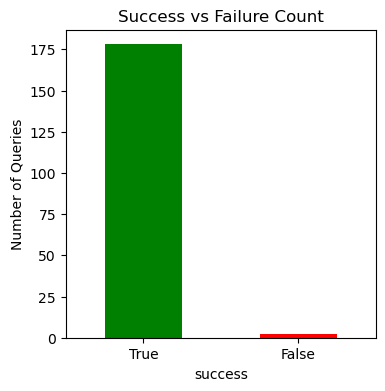

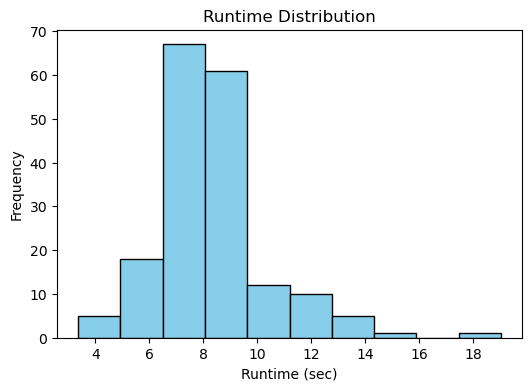

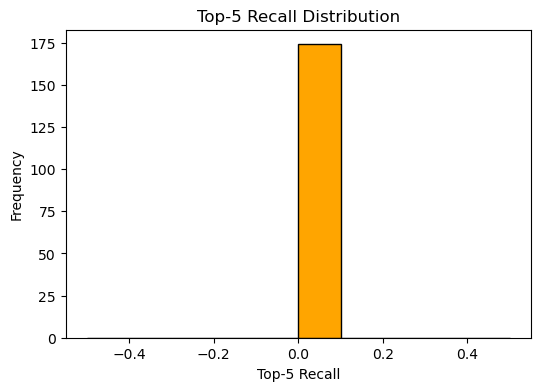

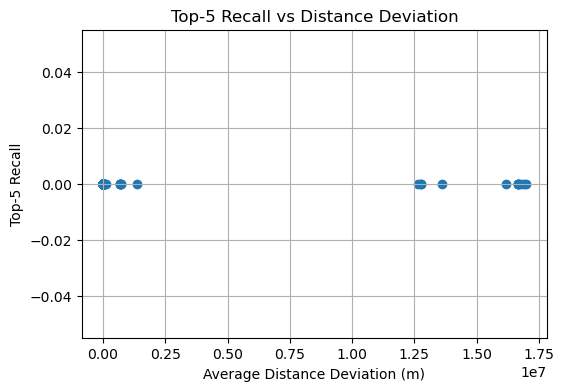

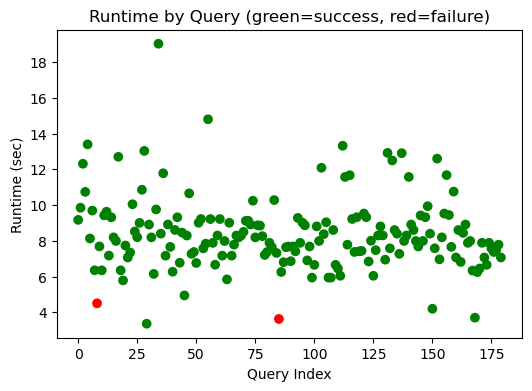

In [13]:
# Convert to DataFrame
df_baseline = pd.DataFrame(baseline_results)

# ---- Compute summary metrics ----
success_rate = df_baseline['success'].mean()  # proportion of True
avg_runtime = df_baseline['runtime_sec'].mean()

# Handle possible None/NaN
avg_top5_recall = df_baseline['top5_recall'].dropna().mean()
avg_dist_dev = df_baseline['avg_dist_dev_m'].dropna().mean()

print(f"Success Rate: {success_rate:.2%}")
print(f"Average Runtime (sec): {avg_runtime:.2f}")
print(f"Average Top-5 Recall: {avg_top5_recall:.2f}")
print(f"Average Distance Deviation (m): {avg_dist_dev:.2f}")

# You can also compute other metrics:
# e.g. error rate
error_rate = df_baseline['error'].notna().mean()
print(f"Error Rate: {error_rate:.2%}")

# ---- Draw some graphs ----

# 1. Success vs Fail Count
plt.figure(figsize=(4,4))
df_baseline['success'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Success vs Failure Count')
plt.ylabel('Number of Queries')
plt.xticks(rotation=0)
plt.show()

# 2. Runtime distribution
plt.figure(figsize=(6,4))
df_baseline['runtime_sec'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')
plt.title('Runtime Distribution')
plt.xlabel('Runtime (sec)')
plt.ylabel('Frequency')
plt.show()

# 3. Top-5 Recall distribution
plt.figure(figsize=(6,4))
df_baseline['top5_recall'].dropna().plot(kind='hist', bins=10, color='orange', edgecolor='black')
plt.title('Top-5 Recall Distribution')
plt.xlabel('Top-5 Recall')
plt.ylabel('Frequency')
plt.show()

# 4. Scatter plot: Distance deviation vs Top5 recall
if df_baseline['avg_dist_dev_m'].notna().any() and df_baseline['top5_recall'].notna().any():
    plt.figure(figsize=(6,4))
    plt.scatter(df_baseline['avg_dist_dev_m'], df_baseline['top5_recall'])
    plt.title('Top-5 Recall vs Distance Deviation')
    plt.xlabel('Average Distance Deviation (m)')
    plt.ylabel('Top-5 Recall')
    plt.grid(True)
    plt.show()

# 5. Optional: runtime vs success scatter
plt.figure(figsize=(6,4))
colors = df_baseline['success'].map({True:'green', False:'red'})
plt.scatter(df_baseline.index, df_baseline['runtime_sec'], c=colors)
plt.title('Runtime by Query (green=success, red=failure)')
plt.xlabel('Query Index')
plt.ylabel('Runtime (sec)')
plt.show()


## Case Study

In [9]:
import folium
import polyline  # to decode Google encoded polyline strings

# 1️⃣ your polyline(s)
polylines = ['rlveFocmsZO`@oFmBI@[KC@gA~FGVaC_ASGfAoS\\mLPeC`@gDXcEz@oOzEq}@l@gMj@iHb@yC~EuUVSP?NLHX@b@Kb@QZSPk@Pi@?e@K]OaDsCkBuA{BmA{Ae@gB[iEa@SIiFN{ARaGbAcCRiBBwCGgFc@u@Bg@CmAO{EO}D[}Ce@oD}@YM_@]Wc@t@aMd@gKTmDBkDFmDEgFKkDWiDQyAy@uDk@uBwByFSi@]yAOuACq@PiBF_@DI|@yOXgBd@}An@uAv@gAx@s@LUd@_@LMPa@Hq@LcDN}APa@b@a@bB_AJAfA}@l@w@x@yATo@Nq@LwAHuAN{AZ}At@kBj@cA~@kC\\}A?c@RmBHa@AuAMoA]aBYs@o@cAOI_@e@MYG_@IWDsAf@_JtA_ZHqCI_CEeAB{@VkEZsHEk@Gi@eGuRMs@sBsGMOiAgD_@cAaBmFsA}DeDaLwAoEmAcC[U}JeKuA_BKQo@y@s@q@yAeBu@g@o@Q}VuCcD_@cPgBiGy@e@M_DWiAM`@mGuJkA]vFbI`A',
             'ftpeFu}~sZvIhApFj@xUjClTzB`ANz@\\hBfBVZpBnBtAjA`JrJd@j@^\\V?tBpGn@hB`FxPh@`BlAnDVpAt@hC?TxBdHLLRf@b@ThD^pBLRDHFP\\FP{AxYaArT{Bbc@?dALb@F\\\\r@@Pr@hA^jAXzAHvA?x@BPAhABXFLb@ZN\\@VGXKPo@f@c@XsArAC@}@fBe@lAYvAU|BCr@MvASz@a@bA}@tAk@n@u@j@GNaBhAc@f@M`@WzFKh@Y`@]Vi@Zy@r@w@fAo@tAe@|AYfB}@xO?RAZGd@?bBJnAXhArAlCnAlD|@hDb@|BX`CVxDFvDGhDKdEAnABn@C`BkAjUId@k@|LxC`@vLnAMfCFL{@dPIrABFd@J`LjAdD\\aArPEPCfAj@nAbLvUnKxTJeAP_D|@yKfAmNHYX]']

# 2️⃣ ground truth POIs
ground_truth = [
    {"name": "Precinct ATM Fitzroy", "lat": -37.7984803, "lon": 144.9783015},
    {"name": "NAB ATM", "lat": -37.8077215, "lon": 144.9580248},
    {"name": "atmx Royal Childrens Hospital", "lat": -37.793845999999995, "lon": 144.9488544},
    {"name": "Next ATM", "lat": -37.7992924, "lon": 144.9843256},
    {"name": "Precinct ATM Fitzroy", "lat": -37.7984803, "lon": 144.9783015},
    {"name": "Amazing ATMs", "lat": -37.7793503, "lon": 144.9873964}
]

# 3️⃣ system output POIs
# system_outputs = [
#     {"name": "FoodWorks", "lat": -37.8031707, "lon": 144.9490491},
#     {"name": "Woolworths Sunshine Market Place", "lat": -37.7804866, "lon": 144.8319839},
#     {"name": "atmx Royal Childrens Hospital", "lat": -37.793845999999995, "lon": 144.9488544},
#     {"name": "KFL Supermarket Braybrook", "lat": -37.7824939, "lon": 144.8642719},
#     {"name": "Friendly Grocer & Bottlemart", "lat": -37.7911383, "lon": 144.889998}
# ]

# 4️⃣ create the map centered on first polyline start
first_polyline_coords = polyline.decode(polylines[0])
m = folium.Map(location=first_polyline_coords[0], zoom_start=11)

# draw all polylines
for pl in polylines:
    coords = polyline.decode(pl)
    folium.PolyLine(coords, color="blue", weight=4, opacity=0.7).add_to(m)

# ground truth markers (green)
for g in ground_truth:
    folium.Marker(
        location=[g["lat"], g["lon"]],
        popup=g["name"],
        icon=folium.Icon(color="green", icon="ok-sign"),
    ).add_to(m)

# system output markers (red)
# for s in system_outputs:
#     folium.Marker(
#         location=[s["lat"], s["lon"]],
#         popup=s["name"],
#         icon=folium.Icon(color="red", icon="info-sign"),
#     ).add_to(m)

# save
m.save("map_demo.html")
print("Map saved to map_demo.html")

Map saved to map_demo.html


In [3]:
import json

In [4]:
with open('../finalQA_newVer.json', 'r') as f:
    data = json.load(f)

In [6]:
data['Find me an ATM with no withdrawal fees along the way from Footscray Community Arts to South Kensington, passing through High Note.']

{'question': 'Find me a atm along the way from Footscray Community Arts to South Kensington, passing through High Note.',
 'POI_type': 'atm',
 'location_A': 'Footscray Community Arts',
 'location_A_coord': {'latitude': -37.8032059, 'longitude': 144.9069341},
 'location_A_addr': '45 Moreland St, Footscray VIC 3011, Australia',
 'location_B': 'South Kensington',
 'location_B_coord': {'latitude': -37.799717199999996,
  'longitude': 144.92584789999998},
 'location_B_addr': 'West Melbourne VIC 3003, Australia',
 'location_C': 'High Note',
 'location_C_coord': {'latitude': -37.773654, 'longitude': 144.99828399999998},
 'location_C_addr': '220 High St, Northcote VIC 3070, Australia',
 'poly_list': [{'encodedPolyline': 'rlveFocmsZO`@oFmBI@[KC@gA~FGVaC_ASGfAoS\\mLPeC`@gDXcEz@oOzEq}@l@gMj@iHb@yC~EuUVSP?NLHX@b@Kb@QZSPk@Pi@?e@K]OaDsCkBuA{BmA{Ae@gB[iEa@SIiFN{ARaGbAcCRiBBwCGgFc@u@Bg@CmAO{EO}D[}Ce@oD}@YM_@]Wc@t@aMd@gKTmDBkDFmDEgFKkDWiDQyAy@uDk@uBwByFSi@]yAOuACq@PiBF_@DI|@yOXgBd@}An@uAv@gAx@s@LUd@_@LM